# 数据集确认

## taxi数据集测试

In [ ]:
import pandas as pd
import numpy as np
# 7:1:2
dataselists=['train','dev','test']
for dataset_name in dataselists:
    file_path='../data/easy_tpp_data/taxi/'+dataset_name+'.pkl'
    data=pd.read_pickle(file_path)
    print(f'{dataset_name}数据总量:',len(data[dataset_name])*len(data[dataset_name][0]))

train数据总量: 50400
dev数据总量: 7600
test数据总量: 14400


In [3]:
dataset_name='train'
file_path='../data/easy_tpp_data/taxi/'+dataset_name+'.pkl'
data=pd.read_pickle(file_path)
print(data[dataset_name][0])
print(data[dataset_name][1])
print(data[dataset_name][2])
print(len(data[dataset_name]))


[{'idx_event': 1, 'type_event': 8, 'time_since_start': 0.0, 'time_since_last_event': 0.0}, {'idx_event': 2, 'type_event': 3, 'time_since_start': 0.07888888888888888, 'time_since_last_event': 0.07888888888888888}, {'idx_event': 3, 'type_event': 8, 'time_since_start': 0.27666666666666667, 'time_since_last_event': 0.19777777777777777}, {'idx_event': 4, 'type_event': 3, 'time_since_start': 0.37972222222222224, 'time_since_last_event': 0.10305555555555557}, {'idx_event': 5, 'type_event': 8, 'time_since_start': 0.5475, 'time_since_last_event': 0.16777777777777775}, {'idx_event': 6, 'type_event': 3, 'time_since_start': 1.0013888888888889, 'time_since_last_event': 0.4538888888888889}, {'idx_event': 7, 'type_event': 8, 'time_since_start': 1.4066666666666667, 'time_since_last_event': 0.40527777777777785}, {'idx_event': 8, 'type_event': 3, 'time_since_start': 1.8002777777777779, 'time_since_last_event': 0.39361111111111113}, {'idx_event': 9, 'type_event': 8, 'time_since_start': 1.8716666666666666

## hawkes模拟数据集

In [ ]:
import pandas as pd
import numpy as np
# 82:10:6.7
# dataselists=['train','dev','test']
# train传不进去
dataselists=['dev','test']
for dataset_name in dataselists:
    file_path='../data/easy_tpp_data/hawkes/'+dataset_name+'.pkl'
    data=pd.read_pickle(file_path)
    print(f'{dataset_name}数据总量:',len(data[dataset_name])*len(data[dataset_name][0]))

train数据总量: 256000
dev数据总量: 33000
test数据总量: 21000


In [ ]:
import pandas as pd
dataset_name='dev'
file_path='../data/easy_tpp_data/hawkes/'+dataset_name+'.pkl'
data=pd.read_pickle(file_path)
print(data[dataset_name][0])
print(data[dataset_name][1])
print(data[dataset_name][15])
print(len(data[dataset_name]))






[{'idx_event': np.int64(1), 'time_since_last_event': np.float32(0.23689924), 'time_since_last_same_event': np.float32(0.23689924), 'type_event': np.int64(4), 'time_since_start': np.float32(0.23689924)}, {'idx_event': np.int64(2), 'time_since_last_event': np.float32(0.33824807), 'time_since_last_same_event': np.float32(0.57514733), 'type_event': np.int64(3), 'time_since_start': np.float32(0.57514733)}, {'idx_event': np.int64(3), 'time_since_last_event': np.float32(0.09166849), 'time_since_last_same_event': np.float32(0.6668158), 'type_event': np.int64(0), 'time_since_start': np.float32(0.6668158)}, {'idx_event': np.int64(4), 'time_since_last_event': np.float32(0.011642575), 'time_since_last_same_event': np.float32(0.44155914), 'type_event': np.int64(4), 'time_since_start': np.float32(0.6784584)}, {'idx_event': np.int64(5), 'time_since_last_event': np.float32(0.7073073), 'time_since_last_same_event': np.float32(1.3857657), 'type_event': np.int64(1), 'time_since_start': np.float32(1.38576

# wuwen数据集切割

## 固定历史时间长度

In [6]:
from tqdm import tqdm

def split_dataset_by_time(target_data, start_time, train_time, valid_time, test_time):
    """
    根据事件发生时间将数据划分为训练集、验证集和测试集。

    参数:
        target_data: 目标数据列表
        start_time: 起始时间字符串,就是wuwen数据第一个index
        train_time: 训练集时间区间 [start, end]
        valid_time: 验证集时间区间 [start, end]
        test_time: 测试集时间区间 [start, end]

    返回:
        train_dataset, valid_dataset, test_dataset
    """
    train_dataset = []
    valid_dataset = []
    test_dataset = []

    train_start = pd.to_datetime(train_time[0])
    train_end = pd.to_datetime(train_time[1])
    valid_start = pd.to_datetime(valid_time[0])
    valid_end = pd.to_datetime(valid_time[1])
    test_start = pd.to_datetime(test_time[0])
    test_end = pd.to_datetime(test_time[1])

    for i in tqdm(range(len(target_data)), desc="划分数据集进度"):
        new_data = target_data[i]
        # 跳过只有一个事件的数据
        if len(new_data) > 6 or len(new_data) < 2:
            continue
        final_time = new_data[-1]['time_since_start']
        future_event_time = pd.to_datetime(start_time) + pd.Timedelta(seconds=final_time)
        if train_start <= future_event_time <= train_end:
            train_dataset.append(new_data)
        elif valid_start <= future_event_time <= valid_end:
            valid_dataset.append(new_data)
        elif test_start <= future_event_time <= test_end:
            test_dataset.append(new_data)
    return train_dataset, valid_dataset, test_dataset

In [11]:
import pandas as pd
columns_list=['gpu0_util','gpu1_util','gpu2_util','gpu3_util','gpu4_util','gpu5_util','gpu6_util','gpu7_util']
hour=12
second=30
file_path = f'../data/processed_data/event_samples_{hour}h_{second}s.pkl'
data = pd.read_pickle(file_path)
for column in columns_list:
    target_dim = column

    target_data = data[target_dim]
    
    start_time = '2025-07-29 09:42:00'
    train_time = ['2025-07-29 09:42:00', '2025-08-19 09:23:30']
    valid_time = ['2025-08-19 09:24:00', '2025-08-22 09:21:00']
    test_time = ['2025-08-22 09:21:30', '2025-08-28 09:16:30']
    train_dataset, valid_dataset, test_dataset = split_dataset_by_time(target_data, start_time, train_time, valid_time, test_time)
    train_dataset={'dim_process':2,'train':train_dataset}
    valid_dataset={'dim_process':2,'dev':valid_dataset}
    test_dataset={'dim_process':2,'test':test_dataset}
    print("训练集样本数：", len(train_dataset['train']))
    print("验证集样本数：", len(valid_dataset['dev']))
    print("测试集样本数：", len(test_dataset['test']))
    if len(train_dataset['train']) > 0:
        print("训练集第一个样本：", train_dataset['train'][0])
    if len(valid_dataset['dev']) > 0:
        print("验证集第一个样本：", valid_dataset['dev'][0])
    if len(test_dataset['test']) > 0:
        print("测试集第一个样本：", test_dataset['test'][0])
    import pickle
    with open(f'../data/easy_tpp_data/wuwen/fix_pasttime/{hour}h_{second}s_'+column+'_train.pkl', 'wb') as f:
        pickle.dump(train_dataset, f)
    with open(f'../data/easy_tpp_data/wuwen/fix_pasttime/{hour}h_{second}s_'+column+'_valid.pkl', 'wb') as f:
        pickle.dump(valid_dataset, f)
    with open(f'../data/easy_tpp_data/wuwen/fix_pasttime/{hour}h_{second}s_'+column+'_test.pkl', 'wb') as f:
        pickle.dump(test_dataset, f)


训练集样本数： 57363
验证集样本数： 7861
测试集样本数： 19686
训练集第一个样本： [{'idx_event': 1, 'type_event': 0, 'time_since_start': np.float64(106170.0), 'time_since_last_event': 0.0}]
验证集第一个样本： [{'idx_event': 1, 'type_event': np.int64(1), 'time_since_start': np.float64(1729770.0), 'time_since_last_event': 0.0}, {'idx_event': 2, 'type_event': 0, 'time_since_start': np.float64(1730010.0), 'time_since_last_event': np.float64(240.0)}, {'idx_event': 3, 'type_event': np.int64(1), 'time_since_start': np.float64(1730310.0), 'time_since_last_event': np.float64(300.0)}, {'idx_event': 4, 'type_event': 0, 'time_since_start': np.float64(1751190.0), 'time_since_last_event': np.float64(20880.0)}, {'idx_event': 5, 'type_event': 0, 'time_since_start': np.float64(1764030.0), 'time_since_last_event': np.float64(12840.0)}, {'idx_event': 6, 'type_event': np.int64(1), 'time_since_start': np.float64(1764060.0), 'time_since_last_event': np.float64(30.0)}, {'idx_event': 7, 'type_event': np.int64(1), 'time_since_start': np.float64(1896

## 固定历史事件数量

In [8]:
def split_dataset_by_time(target_data, start_time, train_time, valid_time, test_time):
    """
    根据事件发生时间将数据划分为训练集、验证集和测试集。

    参数:
        target_data: 目标数据列表
        start_time: 起始时间字符串
        train_time: 训练集时间区间 [start, end]
        valid_time: 验证集时间区间 [start, end]
        test_time: 测试集时间区间 [start, end]

    返回:
        train_dataset, valid_dataset, test_dataset
    """
    train_dataset = []
    valid_dataset = []
    test_dataset = []

    train_start = pd.to_datetime(train_time[0])
    train_end = pd.to_datetime(train_time[1])
    valid_start = pd.to_datetime(valid_time[0])
    valid_end = pd.to_datetime(valid_time[1])
    test_start = pd.to_datetime(test_time[0])
    test_end = pd.to_datetime(test_time[1])

    for i in range(len(target_data)):
        new_data = target_data[i]
        final_time = new_data[-1]['time_since_start']
        future_event_time = pd.to_datetime(start_time) + pd.Timedelta(seconds=final_time)
        if train_start <= future_event_time <= train_end:
            train_dataset.append(new_data)
        elif valid_start <= future_event_time <= valid_end:
            valid_dataset.append(new_data)
        elif test_start <= future_event_time <= test_end:
            test_dataset.append(new_data)
    return train_dataset, valid_dataset, test_dataset

In [10]:
import pandas as pd
columns_list=['gpu0_util','gpu1_util','gpu2_util','gpu3_util','gpu4_util','gpu5_util','gpu6_util','gpu7_util']
for column in columns_list:
    target_dim = column
    file_path = '../data/processed_data/event_samples_past5_future1.pkl'
    data = pd.read_pickle(file_path)
    target_data = data[target_dim]


    start_time = '2025-07-29 09:42:00'
    train_time = ['2025-07-29 09:42:00', '2025-08-19 09:23:30']
    valid_time = ['2025-08-19 09:24:00', '2025-08-22 09:21:00']
    test_time = ['2025-08-22 09:21:30', '2025-08-28 09:16:30']
    train_dataset, valid_dataset, test_dataset = split_dataset_by_time(target_data, start_time, train_time, valid_time, test_time)
    train_dataset={'dim_process':2,'train':train_dataset}
    valid_dataset={'dim_process':2,'dev':valid_dataset}
    test_dataset={'dim_process':2,'test':test_dataset}
    print("训练集样本数：", len(train_dataset['train']))
    print("验证集样本数：", len(valid_dataset['dev']))
    print("测试集样本数：", len(test_dataset['test']))
    if len(train_dataset['train']) > 0:
        print("训练集第一个样本：", train_dataset['train'][0])
    if len(valid_dataset['dev']) > 0:
        print("验证集第一个样本：", valid_dataset['dev'][0])
    if len(test_dataset['test']) > 0:
        print("测试集第一个样本：", test_dataset['test'][0])
    import pickle
    with open('../data/easy_tpp_data/wuwen/fix_event/'+column+'_train.pkl', 'wb') as f:
        pickle.dump(train_dataset, f)
    with open('../data/easy_tpp_data/wuwen/fix_event/'+column+'_valid.pkl', 'wb') as f:
        pickle.dump(valid_dataset, f)
    with open('../data/easy_tpp_data/wuwen/fix_event/'+column+'_test.pkl', 'wb') as f:
        pickle.dump(test_dataset, f)


训练集样本数： 140
验证集样本数： 193
测试集样本数： 646
训练集第一个样本： [{'idx_event': 1, 'type_event': 0, 'time_since_start': 106170.0, 'time_since_last_event': 0.0}, {'idx_event': 2, 'type_event': 1, 'time_since_start': 142800.0, 'time_since_last_event': 36630.0}, {'idx_event': 3, 'type_event': 0, 'time_since_start': 142860.0, 'time_since_last_event': 60.0}, {'idx_event': 4, 'type_event': 1, 'time_since_start': 142980.0, 'time_since_last_event': 120.0}, {'idx_event': 5, 'type_event': 0, 'time_since_start': 160770.0, 'time_since_last_event': 17790.0}, {'idx_event': 6, 'type_event': 1, 'time_since_start': 167070.0, 'time_since_last_event': 6300.0}]
验证集第一个样本： [{'idx_event': 1, 'type_event': 0, 'time_since_start': 1730010.0, 'time_since_last_event': 0.0}, {'idx_event': 2, 'type_event': 1, 'time_since_start': 1730310.0, 'time_since_last_event': 300.0}, {'idx_event': 3, 'type_event': 0, 'time_since_start': 1751190.0, 'time_since_last_event': 20880.0}, {'idx_event': 4, 'type_event': 0, 'time_since_start': 1764030.0,

# easytpp输出结果检验

In [48]:
import numpy as np
import pickle as pkl

# 读取结果
file_path = '../test_results.pkl'
results = pkl.load(open(file_path, 'rb'))

# 01矩阵（事件类型）计算acc
pred_event = results['pred'][1]  # shape: (1170, 5)
true_event = results['label'][1]  # shape: (1170, 5)

# 计算准确率
event_mask = np.isfinite(pred_event) & np.isfinite(true_event)
correct = (pred_event[event_mask] == true_event[event_mask]).sum()
total = event_mask.sum()
acc = correct / total if total > 0 else np.nan
print(f"事件类型（01矩阵）准确率（ACC）：{acc:.4f}")

# 时间diff矩阵计算RMSE
pred_time = results['pred'][0]  # shape: (1170, 5)
true_time = results['label'][0]  # shape: (1170, 5)

# 只对有限值计算RMSE
time_mask = np.isfinite(pred_time) & np.isfinite(true_time)
mse = ((pred_time[time_mask] - true_time[time_mask]) ** 2).mean() if time_mask.sum() > 0 else np.nan
rmse = np.sqrt(mse) if mse is not np.nan else np.nan
print(f"时间diff（RMSE）：{rmse:.4f}")

事件类型（01矩阵）准确率（ACC）：0.4257
时间diff（RMSE）：6483.6952


{'pred': [array([[3.77237296e+00, 4.24401551e-01, 1.49898827e-01, 3.08018059e-01,
        8.44110698e-02],
       [7.41762109e-03, 7.93550014e-01, 3.94081205e-01, 3.64331245e-01,
        4.89585638e-01],
       [1.12776363e+00, 3.00724506e-01, 4.40436214e-01, 6.35979027e-02,
        2.84490615e-01],
       [4.09003377e-01, 3.58870596e-01, 1.84012699e+00, 9.71538853e-03,
        5.67706287e-01],
       [9.91504133e-01, 1.92567661e-01, 1.03188384e+00, 8.49574447e-01,
        1.09327972e+00],
       [3.50720167e-01, 5.06232977e-01, 1.56731653e+00, 4.02674198e+00,
        5.50526381e-01],
       [1.26904190e-01, 4.83735539e-02, 1.87943468e-03, 4.60459068e-02,
        2.94535947e+00],
       [9.61195603e-02, 2.88980722e-01, 3.85491133e-01, 5.86185694e-01,
        6.02007031e-01],
       [1.44936919e+00, 8.54540691e-02, 1.53508520e+00, 3.13101321e-01,
        3.22684720e-02],
       [2.17376947e+00, 1.60700309e+00, 2.63254374e-01, 6.11302257e-01,
        8.33113313e-01],
       [2.79688776e-

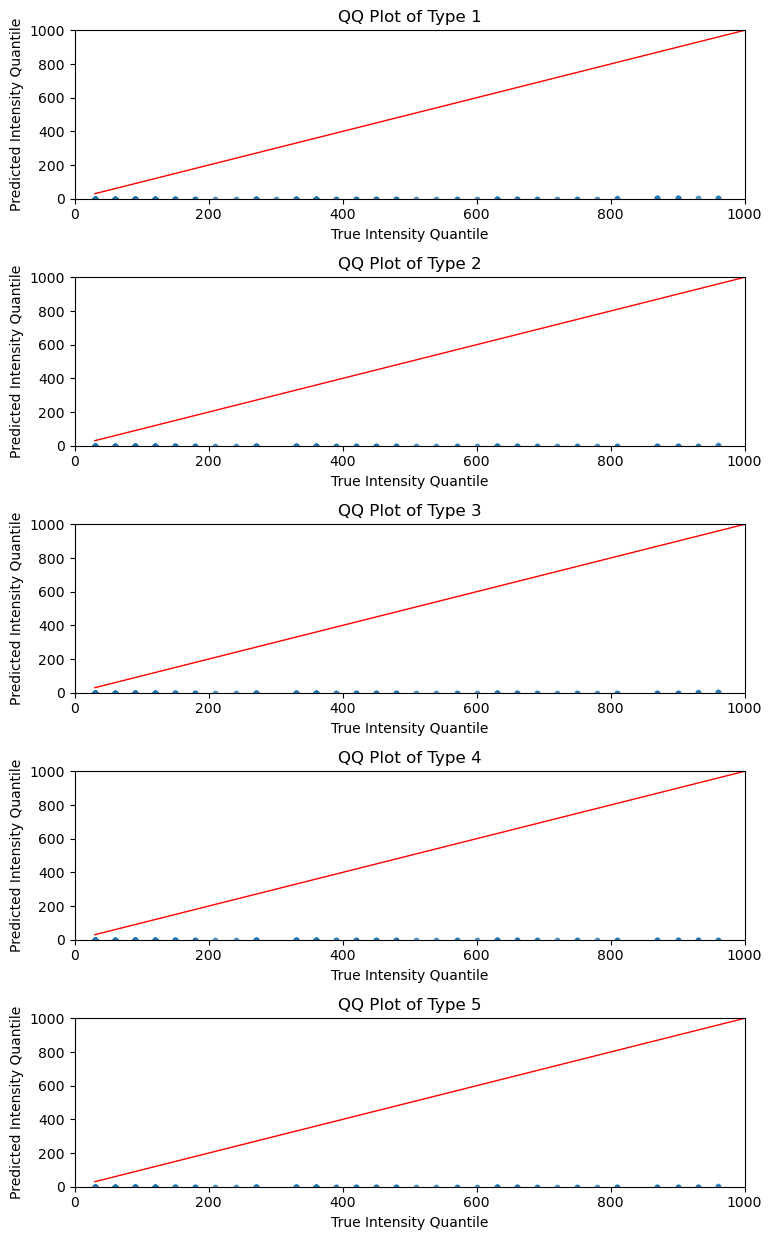

In [1]:
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

# 读取结果
file_path = '../train_results.pkl'
results = pkl.load(open(file_path, 'rb'))
print(results)
# 获取预测和真实强度
pred_intensity = results['pred'][0]  # shape: (646, 5)

true_intensity = results['label'][0]  # shape: (646, 5)

num_types = pred_intensity.shape[1]

plt.figure(figsize=(8, 2.5 * num_types))

for i in range(num_types):
    plt.subplot(num_types, 1, i + 1)
    # 取出第i类的所有预测和真实强度
    pred_i = pred_intensity[:, i]
    true_i = true_intensity[:, i]
    # 去除nan和inf
    mask = np.isfinite(pred_i) & np.isfinite(true_i)
    pred_i = pred_i[mask]
    true_i = true_i[mask]
    # 计算分位数
    pred_sorted = np.sort(pred_i)
    true_sorted = np.sort(true_i)
    min_len = min(len(pred_sorted), len(true_sorted))
    pred_sorted = pred_sorted[:min_len]
    true_sorted = true_sorted[:min_len]
    # 绘制QQ图
    plt.scatter(true_sorted, pred_sorted, s=10, alpha=0.7)
    plt.plot([true_sorted[0], true_sorted[-1]], [true_sorted[0], true_sorted[-1]], 'r-', linewidth=1)
    plt.xlabel('True Intensity Quantile')
    plt.ylabel('Predicted Intensity Quantile')
    plt.title(f'QQ Plot of Type {i+1}')
    plt.tight_layout()
    plt.xlim(0, 1000)
    plt.ylim(0, 1000)
    
plt.show()